# **Cuaderno 4.3 Deep neural networks**

Esta red investiga la conversión de redes neuronales a formato matricial.

Trabaje a través de las celdas de abajo, ejecutando cada celda a su vez. En varios lugares verá las palabras "PENDIENTE". Siga las instrucciones en estos lugares y haga predicciones sobre lo que va a suceder o escriba código para completar las funciones.

Contácteme en udlbookmail@gmail.com si encuentra algún error o tiene alguna sugerencia.

In [11]:
# Importa la librería de matemáticas
import numpy as np
# Importa la librería de trazado
import matplotlib.pyplot as plt

In [12]:
# Define la función de Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [13]:
# Define una shallow neural network con una entrada, una salida y tres unidades ocultas
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Líneas iniciales
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Funciones de activación
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Activaciones ponderadas
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combinar activación ponderada y añadir desplazamiento y
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Devolver todo lo que hemos calculado
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [14]:
# # Trazar la shallow neural network. Asumiremos que la entrada está en el rango [-1,1] y la salida en [-1,1]
# Si la bandera plot_all se establece en true, entonces trazaremos todas las etapas intermedias como en la Figura 3.3
def plot_neural(x, y):
  fig, ax = plt.subplots()
  ax.plot(x.T,y.T)
  ax.set_xlabel('Entrada'); ax.set_ylabel('Salida')
  ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
  ax.set_aspect(1.0)
  plt.show()

Vamos a definir una red. Consideraremos las entradas y salidas en el rango [-1,1]. Si se establece la bandera "plot_all" en True, podrá ver los detalles de cómo se creó.

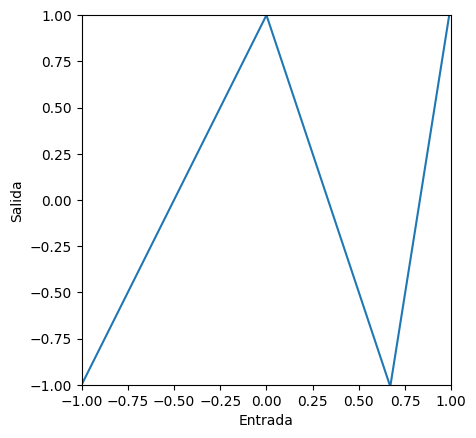

In [15]:
# Ahora definamos algunos parámetros y ejecutemos la primera red neuronal
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Define un rango de valores de entrada
n1_in = np.arange(-1,1,0.01).reshape([1,-1])

# Ejecutamos la red neuronal para cada uno de estos valores de entrada
n1_out, *_ = shallow_1_1_3(n1_in, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# Y luego lo graficamos
plot_neural(n1_in, n1_out)

Ahora definiremos la misma red neuronal, pero esta vez, usaremos la forma matricial. Cuando lo hagas bien, dibujará el mismo gráfico que el anterior.

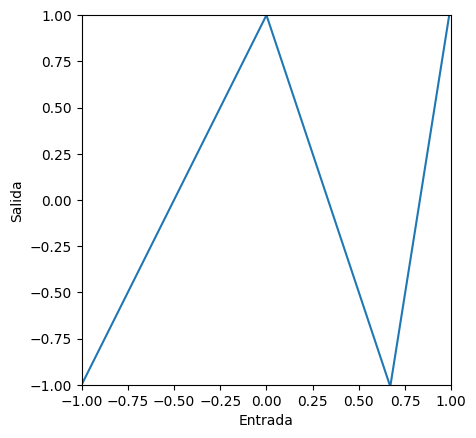

In [16]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1))
Omega_1 = np.zeros((1,3))

# PENDIENTE Rellena los valores de las matrices beta y Omega con los parámetros n1_theta y n1_phi que definen la
# red anterior!!! ¡TENGA EN CUENTA QUE LAS MATRICES SE INDEXAN CONVENCIONALMENTE CON a_11 EN LA ESQUINA SUPERIOR IZQUIERDA, PERO LOS NDARRAYS
# EMPIEZAN EN [0,0]!
# Para empezar, he rellenado un par:
beta_0[0,0] = n1_theta_10
beta_0[1,0] = n1_theta_20
beta_0[2,0] = n1_theta_30

Omega_0[0,0] = n1_theta_11
Omega_0[1,0] = n1_theta_21
Omega_0[2,0] = n1_theta_31

beta_1[0,0] = n1_phi_0

Omega_1[0,0] = n1_phi_1
Omega_1[0,1] = n1_phi_2
Omega_1[0,2] = n1_phi_3

# Asegurarse de que la matriz de datos de entrada tenga diferentes entradas en sus columnas
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in,(n_dim_in,n_data))

# Esto ejecuta la red para TODAS las entradas, x a la vez para que podamos dibujar el gráfico
h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(Omega_0,n1_in_mat))
n1_out = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(Omega_1,h1)

# Dibuja la red y comprueba que se ve igual que el caso no matricial
plot_neural(n1_in, n1_out)

Ahora alimentaremos la salida de la primera red a la segunda.

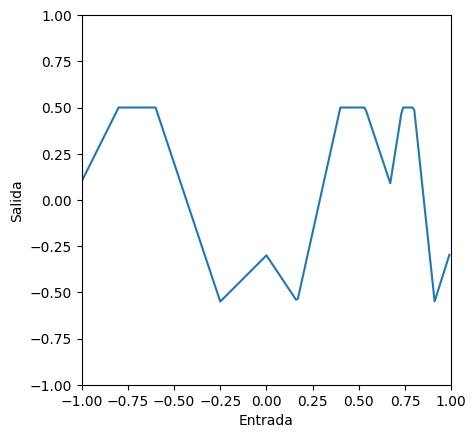

In [17]:
# Ahora definamos algunos parámetros y ejecutemos la segunda red neuronal
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Define un rango de valores de entrada
n2_in = np.arange(-1,1,0.01)

# Ejecutamos la segunda red neuronal sobre la salida de la primera red
n2_out, *_ = \
    shallow_1_1_3(n1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# Y luego lo graficamos
plot_neural(n1_in, n2_out)

Ahora hagamos una red profunda con 3 capas ocultas. Tendrá $D_i=4$ entradas, $D_1=5$ neuronas en la primera capa, $D_2=2$ neuronas en la segunda capa y $D_3=4$ neuronas en la tercera capa, y $D_o = 1$ salida. Consulte la figura 4.6 y las ecuaciones 4.15 para obtener orientación.

In [19]:
# definir tamaños
D_i=4; D_1=5; D_2=2; D_3=4; D_o=1
# Elegiremos las entradas y parámetros de esta red aleatoriamente usando np.random.normal
# Por ejemplo, estableceremos la entrada usando
n_data = 4;
x = np.random.normal(size=(D_i, n_data))
# PENDIENTE inicializa los parámetros aleatoriamente con los tamaños correctos
# Reemplaza las líneas siguientes
beta_0 = np.random.normal(size=(5,1))
Omega_0 = np.random.normal(size=(5,4))
beta_1 = np.random.normal(size=(2,1))
Omega_1 = np.random.normal(size=(2,5))
beta_2 = np.random.normal(size=(4,1))
Omega_2 = np.random.normal(size=(4,2))
beta_3 = np.random.normal(size=(1,1))
Omega_3 = np.random.normal(size=(1,4))


# Si establece los parámetros en los tamaños correctos, el siguiente código se ejecutará
h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(Omega_0,x));
h2 = ReLU(np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(Omega_1,h1));
h3 = ReLU(np.matmul(beta_2,np.ones((1,n_data))) + np.matmul(Omega_2,h2));
y = np.matmul(beta_3,np.ones((1,n_data))) + np.matmul(Omega_3,h3)

if h1.shape[0] is not D_1 or h1.shape[1] is not n_data:
  print("h1 tiene una forma incorrecta")
if h2.shape[0] is not D_2 or h1.shape[1] is not n_data:
  print("h2 tiene una forma incorrecta")
if h3.shape[0] is not D_3 or h1.shape[1] is not n_data:
  print("h3 tiene una forma incorrecta")
if y.shape[0] is not D_o or h1.shape[1] is not n_data:
  print("La salida tiene una forma incorrecta")

# Imprimir las entradas y salidas
print("Puntos de datos de entrada")
print(x)
print ("Puntos de datos de salida")
print(y)

Puntos de datos de entrada
[[-0.7179337  -0.57226592 -1.30407478  0.40688322]
 [ 1.33501821 -0.44766537  0.20037187 -0.6413574 ]
 [-0.03016665 -0.32251787 -1.47865854  0.23779633]
 [-0.52898408 -0.8004132   0.32892606 -0.82610528]]
Puntos de datos de salida
[[-0.34512002 -0.18218133 -0.18218133 -0.18218133]]
